# 从固定 ideal 基线分批注入 CW

流程只有三步：保存一套 `make_ideal` 后的基线；每个频率批次都从它深复制；每批写入自己的目录且不覆盖旧结果。

## 1. 导入

In [1]:
from copy import deepcopy
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from pint import toa as pint_toa
from pint.logging import setup as setup_pint_logging
from pint.models import get_model
from pint.residuals import Residuals
from pta_replicator.deterministic import add_cgw
from pta_replicator.simulate import SimulatedPulsar, make_ideal, simulate_pulsar

setup_pint_logging(level="WARNING")

libstempo not installed. PINT or libstempo are required to use par and tim files.


1

## 2. 参数

In [2]:
obstime = np.arange(53000, 56650, 14)
N_PSR = 25

T_seconds = (obstime[-1] - obstime[0]) * 86400.0
f = 1.0 / T_seconds

source_ra = np.deg2rad(2.0)
source_dec = np.deg2rad(0.4)
gwphi = source_ra
gwtheta = np.pi / 2.0 - source_dec

# 增加频率时，只需在这里多写一行。
CW_BATCHES = [
    {"label": "k5p5", "k0": 5, "delta": 0.5},
]
ANALYSIS_BATCH = "k5p5"

assert len({item["label"] for item in CW_BATCHES}) == len(CW_BATCHES)
assert ANALYSIS_BATCH in {item["label"] for item in CW_BATCHES}

In [3]:
template_par = Path("data/JPSR00.par")
data_root = Path("cw_batch_data")
model_par_dir = data_root / "model_par" / "baseline_v1"
ideal_dir = data_root / "ideal" / "baseline_v1"
cw_root = data_root / "cw"
psr_names = [f"J{i:02d}" for i in range(N_PSR)]

## 3. 生成或加载 ideal 基线

In [4]:
def fibonacci_sphere(n):
    i = np.arange(n)
    golden_ratio = (1 + np.sqrt(5)) / 2
    z = 1 - 2 * (i + 0.5) / n
    ra = np.mod(2 * np.pi * i / golden_ratio, 2 * np.pi)
    dec = np.arcsin(z)
    return ra, dec

In [5]:
def load_ideal_psr(parfile, timfile):
    model = get_model(parfile)

    # 传入 model，确保 PINT 使用 par 文件中的 TT(BIPM2016)。
    toas = pint_toa.get_TOAs(
        timfile, model=model, ephem="DE440", planets=True, usepickle=False
    )

    return SimulatedPulsar(
        ephem="DE440",
        model=model,
        toas=toas,
        residuals=Residuals(toas, model),
        name=model.PSR.value,
        loc={"RAJ": model.RAJ.value, "DECJ": model.DECJ.value},
        added_signals={},
        added_signals_time={},
    )

In [6]:
ra_list, dec_list = fibonacci_sphere(N_PSR)

if not model_par_dir.exists():
    model_par_dir.mkdir(parents=True)

    for name, ra, dec in zip(psr_names, ra_list, dec_list):
        model = get_model(template_par)
        model.PSR.value = name
        model.RAJ.quantity = ra * u.rad
        model.DECJ.quantity = dec * u.rad
        model.setup()
        model.validate()
        model.write_parfile(model_par_dir / f"{name}.par")

parfiles = sorted(model_par_dir.glob("*.par"))
if [path.stem for path in parfiles] != psr_names:
    raise RuntimeError(f"{model_par_dir} 中的 par 文件不完整")

print(f"模型 par 文件：{len(parfiles)} 个")

模型 par 文件：25 个


In [7]:
if not ideal_dir.exists():
    ideal_dir.mkdir(parents=True)

    for parfile in parfiles:
        psr = simulate_pulsar(
            parfile=str(parfile),
            obstimes=obstime,
            toaerr=0.1,
            freq=1440.0,
            observatory="AXIS",
            ephem="DE440",
        )
        make_ideal(psr)
        psr.write_partim(
            ideal_dir / f"{psr.name}.par",
            ideal_dir / f"{psr.name}.tim",
            tempo2=True,
        )
    print("ideal 基线已保存")
else:
    print("ideal 基线已存在，直接使用，不覆盖")

ideal_pars = sorted(ideal_dir.glob("*.par"))
ideal_tims = sorted(ideal_dir.glob("*.tim"))
if [p.stem for p in ideal_pars] != psr_names or [p.stem for p in ideal_tims] != psr_names:
    raise RuntimeError(f"{ideal_dir} 中的 par/tim 文件不完整")

ideal_psrs = [load_ideal_psr(par, tim) for par, tim in zip(ideal_pars, ideal_tims)]
print(f"ideal 脉冲星：{len(ideal_psrs)} 颗，每颗 {len(ideal_psrs[0].toas)} 个 TOA")

ideal 基线已存在，直接使用，不覆盖


ideal 脉冲星：25 颗，每颗 261 个 TOA


## 4. 每个频率从 ideal 独立注入

In [8]:
def inject_cw(ideal_psrs, fgw):
    injected_psrs = deepcopy(ideal_psrs)

    for psr in injected_psrs:
        add_cgw(
            psr=psr,
            gwtheta=gwtheta,
            gwphi=gwphi,
            mc=1.0e9,
            dist=100.0,
            fgw=fgw,
            phase0=0.0,
            psi=0.0,
            inc=np.pi / 3.0,
            psrTerm=False,
            evolve=False,
            phase_approx=False,
            tref=obstime[0] * 86400.0,
            signal_name="cw",
        )

        if set(psr.added_signals) != {f"{psr.name}_cw"}:
            raise RuntimeError(f"{psr.name} 出现重复或意外信号")

    return injected_psrs

In [9]:
ideal_mjds = {psr.name: psr.toas.get_mjds().value.copy() for psr in ideal_psrs}
batch_psrs = {}
batch_frequencies = {}

for batch in CW_BATCHES:
    label = batch["label"]
    fgw = (batch["k0"] + batch["delta"]) * f
    output_dir = cw_root / f"{label}_f{fgw:.12e}Hz"
    injected_psrs = inject_cw(ideal_psrs, fgw)

    if output_dir.exists():
        n_par = len(list(output_dir.glob("*.par")))
        n_tim = len(list(output_dir.glob("*.tim")))
        if (n_par, n_tim) != (N_PSR, N_PSR):
            raise RuntimeError(f"{output_dir} 已存在但文件不完整")
        action = "已存在，不覆盖"
    else:
        output_dir.mkdir(parents=True)
        for psr in injected_psrs:
            psr.write_partim(
                output_dir / f"{psr.name}.par",
                output_dir / f"{psr.name}.tim",
                tempo2=True,
            )
        action = "已保存"

    batch_psrs[label] = injected_psrs
    batch_frequencies[label] = fgw
    print(f"{label}: fgw={fgw:.15e} Hz，{action} -> {output_dir}")

for psr in ideal_psrs:
    assert np.array_equal(psr.toas.get_mjds().value, ideal_mjds[psr.name])
    assert psr.added_signals == {}

psrs = batch_psrs[ANALYSIS_BATCH]
fgw = batch_frequencies[ANALYSIS_BATCH]

k5p5: fgw=1.748829873829874e-08 Hz，已存在，不覆盖 -> cw_batch_data/cw/k5p5_f1.748829873830e-08Hz


## 5. 查看所选批次

### 残差诊断的修正与原因

这里验证的是 **固定计时模型下的 CW 注入增量**，不是重新拟合后的 residual。

1. 比较 $\Delta r=r_{\rm after}-r_{\rm before}$，扣除 ideal 基线中仍可能存在的数值/读写残差。
2. 当前模型没有显式 PHOFF，PINT 默认减去加权均值，因此理论 CW 也必须使用同一权重：$s_\perp=s-\sum_i w_i s_i/\sum_i w_i$，$w_i=1/\sigma_i^2$。权重从 PINT 的 `get_data_error()` 取得。
3. 同时保留 `subtract_mean=False` 的 raw 增量检查；不能仅因中心化后的差值均值为零，就认定注入正确。
4. 单独报告 mean、std、真正的 RMS $=\sqrt{\mathrm{mean}(e^2)}$ 和最大绝对误差。原代码把 `np.std` 标作 RMS，会漏掉常数偏置。

5.5 个周期的有限采样 CW 均值一般不为零，所以原来的 `PINT residual - raw CW` 可以带有常数偏移，并不单独证明 CW 波形错误。新图依次显示 PINT 增量、相同零点约定下的 CW、二者差值；最后一幅保留真实数值误差，不强行置零。代码对全部 25 颗脉冲星同时检查 raw / centered 两条路径。

本节不修改 CW 波形、TOA、计时模型或后续 enterprise 输入。仅去除 Offset 也不等同于一般的 timing-model fit。

官方参考：[PINT Residuals 参数与权重](https://nanograv-pint.readthedocs.io/en/stable/_autosummary/pint.residuals.Residuals.html)、[PINT 相位零点说明](https://nanograv-pint.readthedocs.io/en/latest/explanation.html#offsets-in-pulsar-timing)。

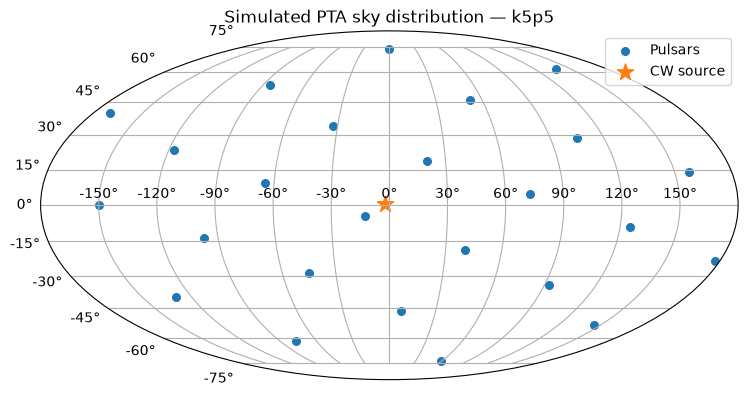

In [10]:
ra = np.array([psr.model.RAJ.quantity.to_value(u.rad) for psr in psrs])
dec = np.array([psr.model.DECJ.quantity.to_value(u.rad) for psr in psrs])
ra_wrapped = (ra + np.pi) % (2.0 * np.pi) - np.pi
source_ra_wrapped = (source_ra + np.pi) % (2.0 * np.pi) - np.pi

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(-ra_wrapped, dec, s=30, label="Pulsars")
ax.scatter(-source_ra_wrapped, source_dec, marker="*", s=150, label="CW source")
ax.grid()
ax.legend()
ax.set_title(f"Simulated PTA sky distribution — {ANALYSIS_BATCH}")
plt.show()

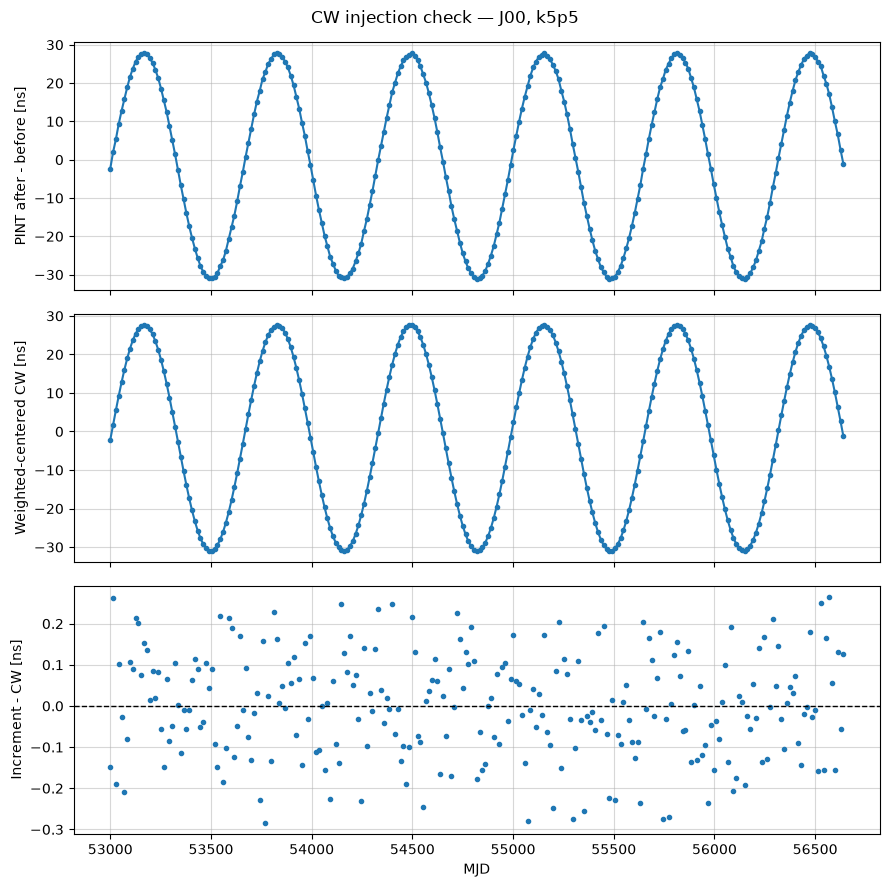

1/T [Hz]: 3.17969067969068e-09
CW frequency [Hz]: 1.748829873829874e-08
Selected pulsar: J00
Weighted CW mean removed [ns]: 1.6866536555513036
baseline: {'mean_ns': 9.720433270559695e-20, 'std_ns': 0.3048738706216134, 'rms_ns': 0.3048738706216134, 'max_abs_ns': 0.6915824059935775}
legacy: {'mean_ns': -1.686653655551304, 'std_ns': 0.3005427445820514, 'rms_ns': 1.713221087631567, 'max_abs_ns': 2.464850534522585}
raw: {'mean_ns': 0.012946297067053405, 'std_ns': 0.12632148284343506, 'rms_ns': 0.12698316280323407, 'max_abs_ns': 0.27797631843906845}
projected: {'mean_ns': -3.582677537461698e-16, 'std_ns': 0.12632148284343503, 'rms_ns': 0.12632148284343503, 'max_abs_ns': 0.283526808617493}
Relative RMS (projected): 0.006128738793485515
CW residual amplitude [ns]: 29.300337230999915
All 25 pulsars, raw: worst RMS=0.131717 ns, max=0.325291 ns
All 25 pulsars, projected: worst RMS=0.131511 ns, max=0.320177 ns
PASS: raw and weighted-centered CW injection checks


In [11]:
def cw_weighted_center(values, weights):
    """使用与 PINT 相同的权重去均值；不修改输入数组。"""
    return values - np.average(values, weights=weights)


def cw_error_stats(error):
    """RMS 包括系统偏置，不能用标准差代替。"""
    return {
        "mean_ns": float(np.mean(error)),
        "std_ns": float(np.std(error)),
        "rms_ns": float(np.sqrt(np.mean(error**2))),
        "max_abs_ns": float(np.max(np.abs(error))),
    }


def diagnose_cw_injection(ideal_psr, injected_psr):
    """固定计时模型下的注入检查，不拟合、不修改 TOA/模型/信号。"""
    if ideal_psr.name != injected_psr.name:
        raise ValueError("ideal 与 injected 脉冲星必须同名")
    if ideal_psr.model.as_parfile(include_info=False) != injected_psr.model.as_parfile(include_info=False):
        raise ValueError("注入前后计时模型不一致，不能只比较 CW 增量")
    if "PhaseOffset" in ideal_psr.model.components:
        raise ValueError("本诊断针对隐式 Offset；显式 PHOFF 需要另行处理")
    if not np.array_equal(ideal_psr.toas.table["index"], injected_psr.toas.table["index"]):
        raise ValueError("注入前后 TOA 的数量或行顺序不一致")
    cw_key = f"{injected_psr.name}_cw"
    if set(injected_psr.added_signals_time) != {cw_key}:
        raise ValueError("需要且只能包含一次 CW 注入")

    # 重新计算，而不是直接复用 psr.residuals 的缓存。
    before = Residuals(ideal_psr.toas, ideal_psr.model,
                       subtract_mean=True, use_weighted_mean=True)
    after = Residuals(injected_psr.toas, injected_psr.model,
                      subtract_mean=True, use_weighted_mean=True)
    sigma = before.get_data_error().to_value(u.ns)
    if not np.array_equal(sigma, after.get_data_error().to_value(u.ns)):
        raise ValueError("注入前后 TOA 权重改变")
    if not np.all(np.isfinite(sigma) & (sigma > 0)):
        raise ValueError("TOA uncertainty 必须为有限正数")
    weights = sigma**-2
    baseline = before.time_resids.to_value(u.ns)
    total = after.time_resids.to_value(u.ns)
    cw_raw = injected_psr.added_signals_time[cw_key].to_value(u.ns)
    if cw_raw.shape != baseline.shape or not np.all(np.isfinite(cw_raw)):
        raise ValueError("CW 数组长度不匹配或包含非有限值")
    cw_projected = cw_weighted_center(cw_raw, weights)
    delta_pint = total - baseline
    difference = delta_pint - cw_projected

    # 独立的 raw 检查保留常数偏置，防止去均值掩盖真实误差。
    before_raw = Residuals(ideal_psr.toas, ideal_psr.model,
                           subtract_mean=False, use_weighted_mean=True)
    after_raw = Residuals(injected_psr.toas, injected_psr.model,
                          subtract_mean=False, use_weighted_mean=True)
    delta_raw = after_raw.time_resids.to_value(u.ns) - before_raw.time_resids.to_value(u.ns)
    raw_difference = delta_raw - cw_raw
    legacy_difference = total - cw_raw
    cw_mean = np.average(cw_raw, weights=weights)
    np.testing.assert_allclose(
        legacy_difference, difference + baseline - cw_mean, rtol=0, atol=1e-10
    )
    return {
        "pulsar": injected_psr.name,
        "delta_pint": delta_pint, "cw_projected": cw_projected,
        "difference": difference, "cw_raw": cw_raw,
        "cw_mean_ns": float(cw_mean),
        "baseline": cw_error_stats(baseline),
        "legacy": cw_error_stats(legacy_difference),
        "raw": cw_error_stats(raw_difference),
        "projected": cw_error_stats(difference),
    }


ideal_by_name = {item.name: item for item in ideal_psrs}
cw_diagnostics = [diagnose_cw_injection(ideal_by_name[item.name], item) for item in psrs]
selected_diagnostic = cw_diagnostics[0]
psr = psrs[0]
# 绘图使用注入前采样时刻；不通过相减 float64 MJD 测量 ns 级 TOA 位移。
toa_mjd = ideal_by_name[psr.name].toas.get_mjds().value
delta_pint = selected_diagnostic["delta_pint"]
cw_projected = selected_diagnostic["cw_projected"]
difference = selected_diagnostic["difference"]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(toa_mjd, delta_pint, ".-")
axes[0].set_ylabel("PINT after - before [ns]")
axes[1].plot(toa_mjd, cw_projected, ".-")
axes[1].set_ylabel("Weighted-centered CW [ns]")
axes[2].plot(toa_mjd, difference, ".")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("Increment - CW [ns]")
axes[2].set_xlabel("MJD")
for ax in axes:
    ax.grid(alpha=0.5)
fig.suptitle(f"CW injection check — {psr.name}, {ANALYSIS_BATCH}")
plt.tight_layout()
plt.show()

print("1/T [Hz]:", f)
print("CW frequency [Hz]:", fgw)
print("Selected pulsar:", psr.name)
print("Weighted CW mean removed [ns]:", selected_diagnostic["cw_mean_ns"])
for convention in ("baseline", "legacy", "raw", "projected"):
    print(f"{convention}:", selected_diagnostic[convention])
signal_rms = np.sqrt(np.mean(cw_projected**2))
relative_rms = selected_diagnostic["projected"]["rms_ns"] / signal_rms if signal_rms > 0 else np.nan
print("Relative RMS (projected):", relative_rms)
print("CW residual amplitude [ns]:", 0.5 * np.ptp(selected_diagnostic["cw_raw"]))
for convention in ("raw", "projected"):
    worst_rms = max(item[convention]["rms_ns"] for item in cw_diagnostics)
    worst_max = max(item[convention]["max_abs_ns"] for item in cw_diagnostics)
    print(f"All {len(cw_diagnostics)} pulsars, {convention}: worst RMS={worst_rms:.6g} ns, max={worst_max:.6g} ns")
    assert worst_rms < 1.0 and worst_max < 3.0, f"{convention} 注入检查超出数值容差"
print("PASS: raw and weighted-centered CW injection checks")

## 6. 转为 enterprise Pulsar

In [12]:
from enterprise.pulsar import Pulsar

enterprise_psrs = [
    Pulsar(psr.toas, psr.model, timing_package="pint", planets=False)
    for psr in psrs
]

for psr in enterprise_psrs[:3]:
    print(psr.name, len(psr.toas), psr.toas.min(), psr.toas.max())

J00 261 4579200239.467906 4893696271.779491
J01 261 4579200104.933258 4893696069.911834
J02 261 4579200484.73054 4893696491.279551


## 7. 单颗脉冲星的频率泄漏

Earth-term 单频 residual 可写为

$$r_a(t)=A_{a,c}\cos(2\pi f_{\rm CW}t)+A_{a,s}\sin(2\pi f_{\rm CW}t),$$

不同脉冲星的两个振幅系数不同，但频率相同。在 $f_k=k/T$ 上的复投影为

$$z_{a,k}=\sum_i r_a(t_i)e^{-2\pi i f_k t_i}.$$

定义采样窗 $W_a(\Delta f)=\sum_i e^{-2\pi i\Delta f t_{a,i}}$，则

$$z_{a,k}=\frac{C_a}{2}W_a(f_k-f_{\rm CW})+\frac{C_a^*}{2}W_a(f_k+f_{\rm CW}),\qquad C_a=A_{a,c}-iA_{a,s}.$$

第二项来自实信号的负频率分量。对 $N$ 个等间隔采样点，

$$W_N(\Delta f)=e^{-i\pi(N-1)\Delta f\Delta t}\frac{\sin(\pi N\Delta f\Delta t)}{\sin(\pi\Delta f\Delta t)},\qquad F_N(\Delta f)=\frac{1}{N}|W_N(\Delta f)|^2.$$

Dirichlet 核描述复振幅泄漏，Fejér 核描述归一化功率泄漏。三条路径分别是：

- Path A：直接投影 $z_k=\sum_i r(t_i)e^{-2\pi i f_k t_i}$；
- Path B：设计矩阵投影 $z_k=(F_{\cos,k}^{T}r)-i(F_{\sin,k}^{T}r)$；
- Path C：用实际采样时刻和单频 CW 模型，通过上面的 $W_a$ 直接预测 $z_k$。

> 三条路径重合只验证注入、单位、Fourier convention 和采样窗实现；这是 implementation validation，不是新的科学结果。

In [13]:
from pta_replicator.constants import DAY_IN_SEC
from pta_replicator.red_noise import create_fourier_design_matrix_red

psr = psrs[0]
ideal_psr = next(item for item in ideal_psrs if item.name == psr.name)
cw_key = f"{psr.name}_cw"

if set(psr.added_signals_time) != {cw_key}:
    raise RuntimeError(f"{psr.name} 的 CW 信号不唯一")

cw_signal = psr.added_signals_time[cw_key].to_value(u.s)
fgw = psr.added_signals[cw_key]["fgw"]

# add_cgw 在 ideal TOA 上计算波形，因此直接使用同名 ideal 脉冲星的采样时刻。
ideal_mjd = np.asarray(ideal_psr.toas.get_mjds().value, dtype=np.longdouble)
t = np.asarray((ideal_mjd - ideal_mjd[0]) * DAY_IN_SEC, dtype=float)
tspan = (
    max(item.toas.max() for item in enterprise_psrs)
    - min(item.toas.min() for item in enterprise_psrs)
)
k_cw = fgw * tspan
k_center = int(np.floor(k_cw))
bin_index = np.arange(max(1, k_center - 4), k_center + 6)
freqs = bin_index / tspan

print(f"Pulsar: {psr.name}")
print(f"N_TOA: {len(t)}")
print(f"PTA Tspan: {tspan / DAY_IN_SEC / 365.25:.6f} yr")
print(f"fgw: {fgw * 1e9:.6f} nHz")
print(f"fgw * Tspan: {k_cw:.6f}")
print(f"Fourier bins: {bin_index[0]} ... {bin_index[-1]}")

Pulsar: J00
N_TOA: 261
PTA Tspan: 9.965807 yr
fgw: 17.488299 nHz
fgw * Tspan: 5.500016
Fourier bins: 1 ... 10


In [14]:
# A: 直接计算 Fourier 投影
fourier_kernel = np.exp(-2j * np.pi * np.outer(freqs, t))
direct_amplitude = fourier_kernel @ cw_signal
direct_power = np.abs(direct_amplitude) ** 2

# B: 使用 pta_replicator 的 cos/sin 设计矩阵
F, _ = create_fourier_design_matrix_red(
    t, modes=freqs, libstempo_convention=True
)
projection = F.T @ cw_signal
matrix_amplitude = projection[0::2] - 1j * projection[1::2]
matrix_power = np.abs(matrix_amplitude) ** 2

In [15]:
# C: 有限采样窗的精确预测
cw_basis = np.column_stack([
    np.cos(2.0 * np.pi * fgw * t),
    np.sin(2.0 * np.pi * fgw * t),
])
cw_coeffs, *_ = np.linalg.lstsq(cw_basis, cw_signal, rcond=None)
cw_reconstructed = cw_basis @ cw_coeffs
monochromatic_error = (
    np.linalg.norm(cw_signal - cw_reconstructed) / np.linalg.norm(cw_signal)
)

# r(t) = Re[C exp(i 2π fgw t)]
complex_amplitude = cw_coeffs[0] - 1j * cw_coeffs[1]

def spectral_window(delta_f, sample_times):
    return np.exp(
        -2j * np.pi * np.outer(delta_f, sample_times)
    ).sum(axis=1)

window_minus = spectral_window(freqs - fgw, t)
window_plus = spectral_window(freqs + fgw, t)
window_amplitude = (
    0.5 * complex_amplitude * window_minus
    + 0.5 * np.conjugate(complex_amplitude) * window_plus
)
window_power = np.abs(window_amplitude) ** 2

In [16]:
def relative_difference(reference, value):
    scale = max(np.max(np.abs(reference)), np.finfo(float).tiny)
    return np.max(np.abs(reference - value)) / scale

matrix_difference = relative_difference(direct_power, matrix_power)
window_difference = relative_difference(direct_power, window_power)

print("Monochromatic reconstruction:", monochromatic_error)
print("Direct vs F-matrix:", matrix_difference)
print("Direct vs sampling window:", window_difference)

assert monochromatic_error < 1e-10
assert matrix_difference < 1e-12
assert window_difference < 1e-12

Monochromatic reconstruction: 3.094518162728408e-14
Direct vs F-matrix: 8.766062795029975e-16
Direct vs sampling window: 1.62015624872429e-15


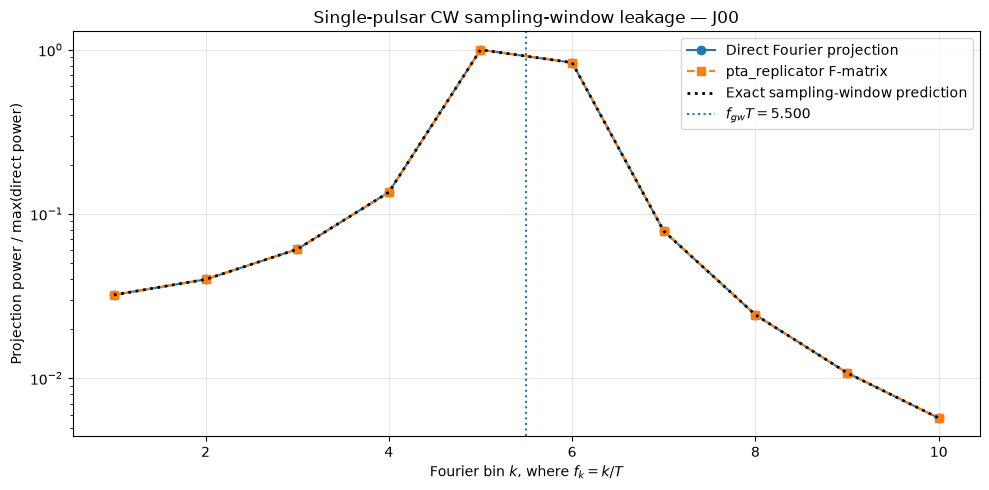

In [17]:
power_scale = direct_power.max()
floor = 1e-16

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(
    bin_index, np.maximum(direct_power / power_scale, floor), "o-",
    label="Direct Fourier projection",
)
ax.semilogy(
    bin_index, np.maximum(matrix_power / power_scale, floor), "s--",
    label="pta_replicator F-matrix",
)
ax.semilogy(
    bin_index, np.maximum(window_power / power_scale, floor), "k:",
    linewidth=2, label="Exact sampling-window prediction",
)
ax.axvline(
    fgw * tspan, linestyle=":",
    label=rf"$f_{{gw}}T={fgw*tspan:.3f}$",
)
ax.set_xlabel(r"Fourier bin $k$, where $f_k=k/T$")
ax.set_ylabel("Projection power / max(direct power)")
ax.set_title(f"Single-pulsar CW sampling-window leakage — {psr.name}")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 8. 最小 PFOS 分析

enterprise 模型只包含 timing model、固定 TOA measurement noise 和名为 `gw` 的 common Fourier recovery template。这里没有注入随机 GWB，也不采样参数。

In [18]:
import pandas as pd

from defiant import OptimalStatistic
from enterprise.signals import gp_signals, parameter, signal_base, utils, white_signals

nfreq = int(bin_index[-1])
timing_model = gp_signals.MarginalizingTimingModel()
measurement_noise = white_signals.MeasurementNoise(
    efac=parameter.Constant(1.0)
)

gw_log10_A = parameter.Uniform(-18, -12)("gw_log10_A")
gw_gamma = parameter.Constant(13.0 / 3.0)("gw_gamma")
gw_spectrum = utils.powerlaw(log10_A=gw_log10_A, gamma=gw_gamma)
gw = gp_signals.FourierBasisGP(
    gw_spectrum, components=nfreq, Tspan=tspan, name="gw"
)

model = timing_model + measurement_noise + gw
pta = signal_base.PTA([model(item) for item in enterprise_psrs])
fixed_params = {"gw_log10_A": -14.0}

print("PTA parameters:", pta.param_names)
print("Fixed parameters:", fixed_params)

PTA parameters: ['gw_log10_A']
Fixed parameters: {'gw_log10_A': -14.0}


In [19]:
os_obj = OptimalStatistic(
    enterprise_psrs, pta, gwb_name="gw", orfs=["hd"], sub_tqdm=False
)
pfos = os_obj.compute_PFOS(
    params=fixed_params,
    N=1,
    pair_covariance=False,
    return_pair_vals=True,
    use_tqdm=False,
)

freqs = os_obj.freqs.copy()
Sk = pfos["Sk"]
Sks = pfos["Sks"]
rhok = pfos["rhok"]
sigk = pfos["sigk"]
Ck = pfos["Ck"]
pair_idx = os_obj.pair_idx.copy()

assert np.allclose(freqs, np.arange(1, nfreq + 1) / tspan)
assert rhok.shape == sigk.shape == (nfreq, len(pair_idx))
assert Ck.shape == (nfreq, len(pair_idx), len(pair_idx))
assert np.all(np.isfinite(rhok)) and np.all(sigk > 0)

for name, values in {"freqs": freqs, "rhok": rhok, "sigk": sigk, "Ck": Ck}.items():
    print(f"{name}: {values.shape}")

freqs: (10,)
rhok: (10, 300)
sigk: (10, 300)
Ck: (10, 300, 300)


In [20]:
map_bins = np.arange(max(1, k_center - 1), k_center + 3)
map_indices = map_bins - 1

if map_indices[-1] >= nfreq:
    raise RuntimeError("PFOS Fourier bins 不足")

pfos_table = pd.DataFrame({
    "bin": map_bins,
    "frequency [nHz]": freqs[map_indices] * 1e9,
    "PFOS estimator": Sk[map_indices],
    "PFOS uncertainty": Sks[map_indices],
})
pfos_table

,bin,frequency [nHz],PFOS estimator,PFOS uncertainty
0,4,12.718725,2.808185e-17,1.571648e-15
1,5,15.898406,2.424547e-16,6.142511e-16
2,6,19.078087,2.393567e-16,2.934307e-16
3,7,22.257768,2.666777e-17,1.635435e-16


## 9. MAPS radiometer map

MAPS 提供 HEALPix grid、脉冲星对顺序和非偏振 point-source response。下面保留未经逐图归一化的 radiometer power，并把 propagation-direction map 转回真实 source direction。

In [21]:
import healpy as hp

from maps import utils as maps_utils
from maps.anis_pta import anis_pta

NSIDE = 8
psrs_theta = np.pi / 2.0 - dec
psrs_phi = ra
maps_obj = anis_pta(psrs_theta, psrs_phi, nside=NSIDE, l_max=0)

defiant_pair_lookup = {
    tuple(pair): index for index, pair in enumerate(pair_idx)
}
pair_order = np.array([
    defiant_pair_lookup[tuple(pair)] for pair in maps_obj.pair_idx
])
rhok_map_order = rhok[:, pair_order]
sigk_map_order = sigk[:, pair_order]

same_pair_order = np.array_equal(pair_idx, maps_obj.pair_idx)
assert np.array_equal(pair_idx[pair_order], maps_obj.pair_idx)
print("DEFIANT/MAPS pair order identical:", same_pair_order)
print("F_mat:", maps_obj.F_mat.shape)

Optional mpi4py package is not installed.  MPI support is not available.


WARNING  (pint.logging                  ): /home/liujiyu/projects/Leakage/.repro-env/lib/python3.11/site-packages/astroML/linear_model/linear_regression_errors.py:10 UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed


DEFIANT/MAPS pair order identical: True
F_mat: (300, 768)


In [22]:
def raw_radiometer_map(maps_obj, rho, sig):
    weights = 1.0 / sig**2
    dirty = maps_obj.F_mat.T @ (weights * rho)
    fisher_diag = np.sum(
        maps_obj.F_mat**2 * weights[:, None], axis=0
    )

    raw_map = np.full(dirty.shape, np.nan)
    raw_err = np.full(dirty.shape, np.nan)
    valid = fisher_diag > 0
    raw_map[valid] = dirty[valid] / fisher_diag[valid]
    raw_err[valid] = 1.0 / np.sqrt(fisher_diag[valid])
    return raw_map, raw_err

In [23]:
raw_propagation_maps = []
raw_source_maps = []
raw_source_errors = []

for index in map_indices:
    raw_map, raw_err = raw_radiometer_map(
        maps_obj, rhok_map_order[index], sigk_map_order[index]
    )
    raw_propagation_maps.append(raw_map)
    raw_source_maps.append(maps_utils.invert_omega(raw_map))
    raw_source_errors.append(maps_utils.invert_omega(raw_err))

raw_propagation_maps = np.asarray(raw_propagation_maps)
raw_source_maps = np.asarray(raw_source_maps)
raw_source_errors = np.asarray(raw_source_errors)

source_pixel = hp.ang2pix(NSIDE, gwtheta, gwphi)
peak_pixels = np.nanargmax(raw_source_maps, axis=1)
peak_theta, peak_phi = hp.pix2ang(NSIDE, peak_pixels)
source_power_raw = raw_source_maps[:, source_pixel]
peak_power_raw = raw_source_maps[np.arange(len(map_bins)), peak_pixels]

source_vector = np.asarray(hp.ang2vec(gwtheta, gwphi))
peak_vectors = np.column_stack(hp.pix2vec(NSIDE, peak_pixels))
peak_offset_deg = np.rad2deg(np.arccos(
    np.clip(peak_vectors @ source_vector, -1.0, 1.0)
))
print("Raw source maps:", raw_source_maps.shape)

Raw source maps: (4, 768)


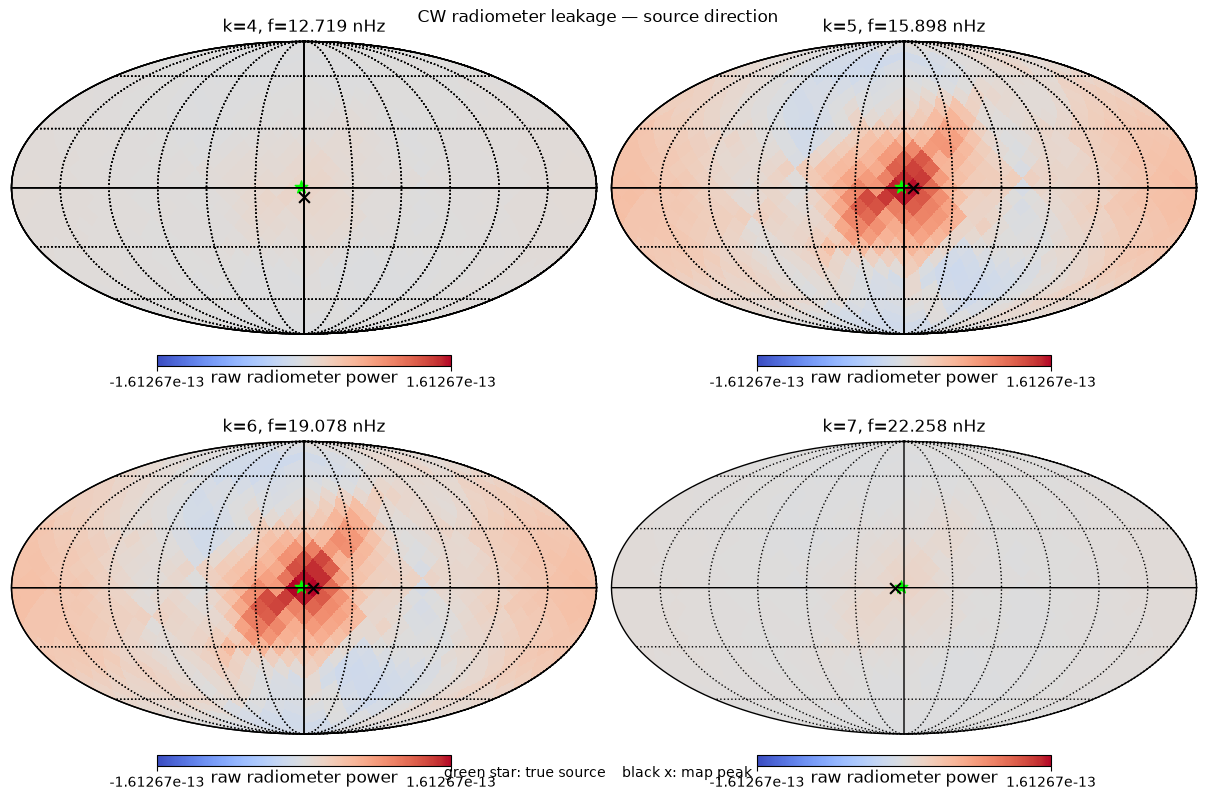

In [24]:
map_limit = np.nanmax(np.abs(raw_source_maps))
fig = plt.figure(figsize=(12, 8))

for panel, (bin_number, index) in enumerate(zip(map_bins, map_indices), start=1):
    hp.mollview(
        raw_source_maps[panel - 1],
        fig=fig.number,
        sub=(2, 2, panel),
        min=-map_limit,
        max=map_limit,
        cmap="coolwarm",
        title=f"k={bin_number}, f={freqs[index] * 1e9:.3f} nHz",
        unit="raw radiometer power",
    )
    hp.projscatter(gwtheta, gwphi, marker="*", color="lime", s=90)
    hp.projscatter(
        peak_theta[panel - 1], peak_phi[panel - 1],
        marker="x", color="black", s=60,
    )
    hp.graticule(verbose=False)

fig.suptitle("CW radiometer leakage — source direction", y=0.98)
fig.text(0.5, 0.02, "green star: true source    black x: map peak", ha="center")
plt.show()

,bin,frequency [nHz],residual power,source map power,peak map power,peak offset [deg]
0,4,12.718725,8.747549e-13,1.651895e-14,1.776282e-14,5.552100
1,5,15.898406,6.450507e-12,1.533051e-13,1.576002e-13,7.635423
2,6,19.078087,5.384449e-12,1.605342e-13,1.612667e-13,7.635423
3,7,22.257768,5.070548e-13,1.873195e-14,1.873195e-14,3.646973


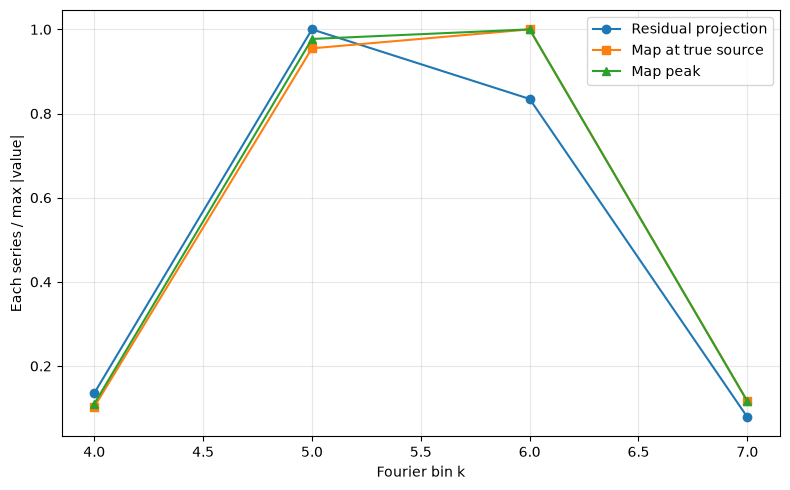

In [25]:
residual_indices = np.array([
    np.flatnonzero(bin_index == value)[0] for value in map_bins
])
residual_power_raw = direct_power[residual_indices]

leakage_table = pd.DataFrame({
    "bin": map_bins,
    "frequency [nHz]": freqs[map_indices] * 1e9,
    "residual power": residual_power_raw,
    "source map power": source_power_raw,
    "peak map power": peak_power_raw,
    "peak offset [deg]": peak_offset_deg,
})
display(leakage_table)

residual_shape = residual_power_raw / np.max(np.abs(residual_power_raw))
source_shape = source_power_raw / np.max(np.abs(source_power_raw))
peak_shape = peak_power_raw / np.max(np.abs(peak_power_raw))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(map_bins, residual_shape, "o-", label="Residual projection")
ax.plot(map_bins, source_shape, "s-", label="Map at true source")
ax.plot(map_bins, peak_shape, "^-", label="Map peak")
ax.set_xlabel("Fourier bin k")
ax.set_ylabel("Each series / max |value|")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

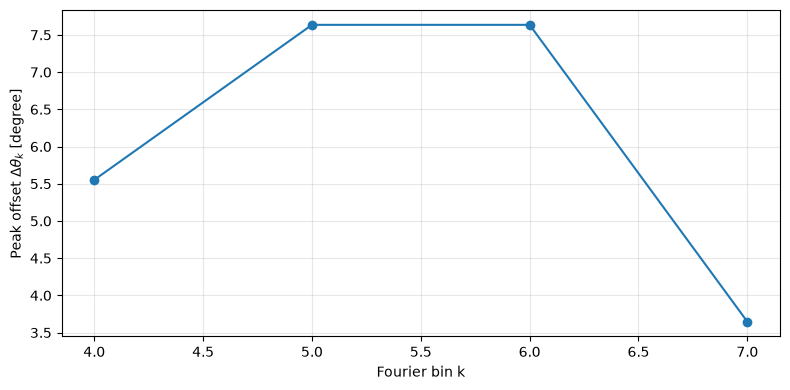

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(map_bins, peak_offset_deg, "o-")
ax.set_xlabel("Fourier bin k")
ax.set_ylabel(r"Peak offset $\Delta\theta_k$ [degree]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 当前 demo 的边界

Fourier 三线重合只验证注入和实现。这里真正检查的是 residual leakage $\rightarrow$ PFOS pair correlations $\rightarrow$ radiometer map leakage。

数据中是确定性、固定偏振的 Earth-term CW；recovery 使用 stochastic common-process 和非偏振 point-source radiometer template，因此 map 泄漏不必严格等于理想 Fejér 核。当前也只有一次固定 $\delta$ 注入，不能据此总结一般规律；连续 $\delta$ 扫描留到下一阶段，完成扫描后再考虑封装成正式项目。

## 11. 连续扫描 $\delta$

固定 $k_0=5$ 和全部物理参数，只令 $\delta$ 从 0 变化到 1。每个频点都重新从 ideal pulsars 注入；下面比较 residual、PFOS 和 radiometer map 中的连续泄漏。

In [27]:
import logging
import time

SCAN_FORMAT_VERSION = 2
SCAN_K0 = 5
delta_values = np.round(np.linspace(0.0, 1.0, 101), 2)
scan_bins = np.arange(1, nfreq + 1)
scan_indices = scan_bins - 1
scan_frequencies = freqs[scan_indices].copy()

scan_path = (
    data_root / "delta_scan" /
    "k5_delta_0p00_1p00_step_0p01_bins1to10_nside8.npz"
)
scan_path.parent.mkdir(parents=True, exist_ok=True)

print(f"delta points: {len(delta_values)}")
print(f"analysis bins: {scan_bins}")
print(f"scan data: {scan_path}")

delta points: 101
analysis bins: [ 1  2  3  4  5  6  7  8  9 10]
scan data: cw_batch_data/delta_scan/k5_delta_0p00_1p00_step_0p01_bins1to10_nside8.npz


In [28]:
scan_data = None
scan_elapsed_seconds = np.nan

if scan_path.exists():
    with np.load(scan_path) as saved:
        scan_data = {name: saved[name].copy() for name in saved.files}

    same_config = (
        int(scan_data["format_version"]) == SCAN_FORMAT_VERSION
        and int(scan_data["k0"]) == SCAN_K0
        and int(scan_data["nside"]) == NSIDE
        and np.array_equal(scan_data["delta_values"], delta_values)
        and np.array_equal(scan_data["scan_bins"], scan_bins)
        and np.array_equal(scan_data["scan_frequencies"], scan_frequencies)
        and float(scan_data["tspan"]) == tspan
        and float(scan_data["source_ra"]) == source_ra
        and float(scan_data["source_dec"]) == source_dec
    )
    if not same_config:
        raise RuntimeError(f"{scan_path} 与当前扫描配置不一致")
    print("扫描结果已存在，直接加载，不覆盖")
else:
    print("扫描结果不存在，开始计算")

扫描结果已存在，直接加载，不覆盖


In [29]:
def scan_residual_power(scan_psrs):
    scan_psr = scan_psrs[0]
    scan_key = f"{scan_psr.name}_cw"
    scan_signal = scan_psr.added_signals_time[scan_key].to_value(u.s)
    scan_kernel = np.exp(-2j * np.pi * np.outer(scan_frequencies, t))
    return np.abs(scan_kernel @ scan_signal) ** 2


def scan_pfos_arrays(scan_psrs):
    scan_enterprise_psrs = [
        Pulsar(item.toas, item.model, timing_package="pint", planets=False)
        for item in scan_psrs
    ]
    scan_pta = signal_base.PTA([model(item) for item in scan_enterprise_psrs])
    scan_os = OptimalStatistic(
        scan_enterprise_psrs, scan_pta,
        gwb_name="gw", orfs=["hd"], sub_tqdm=False,
    )
    result = scan_os.compute_PFOS(
        params=fixed_params, N=1, pair_covariance=False,
        return_pair_vals=True, use_tqdm=False,
    )

    assert len(scan_psrs) == N_PSR
    assert len({tuple(item) for item in scan_os.pair_idx}) == 300
    assert np.array_equal(scan_os.pair_idx, pair_idx)
    assert np.allclose(scan_os.freqs, freqs)
    return (
        result["Sk"][scan_indices], result["Sks"][scan_indices],
        result["rhok"][scan_indices], result["sigk"][scan_indices],
    )

In [30]:
def scan_radiometer_arrays(scan_rho, scan_sig):
    ordered_rho = scan_rho[:, pair_order]
    ordered_sig = scan_sig[:, pair_order]
    source_maps = []
    source_errors = []

    for rho_one_bin, sig_one_bin in zip(ordered_rho, ordered_sig):
        propagation_map, propagation_error = raw_radiometer_map(
            maps_obj, rho_one_bin, sig_one_bin
        )
        source_maps.append(maps_utils.invert_omega(propagation_map))
        source_errors.append(maps_utils.invert_omega(propagation_error))

    source_maps = np.asarray(source_maps)
    source_errors = np.asarray(source_errors)
    peaks = np.nanargmax(source_maps, axis=1)
    peak_vectors = np.column_stack(hp.pix2vec(NSIDE, peaks))
    offsets = np.rad2deg(np.arccos(
        np.clip(peak_vectors @ source_vector, -1.0, 1.0)
    ))
    at_source = source_maps[:, source_pixel]
    at_peak = source_maps[np.arange(len(scan_bins)), peaks]
    error_at_source = source_errors[:, source_pixel]
    error_at_peak = source_errors[np.arange(len(scan_bins)), peaks]
    return (
        source_maps, at_source, at_peak,
        error_at_source, error_at_peak, peaks, offsets,
    )

In [31]:
if scan_data is None:
    n_delta = len(delta_values)
    n_bin = len(scan_bins)
    n_pair = len(pair_idx)
    n_pixel = hp.nside2npix(NSIDE)

    injection_frequencies = (SCAN_K0 + delta_values) * f
    k_cw_values = injection_frequencies * tspan
    residual_power = np.empty((n_delta, n_bin))
    pfos_estimator = np.empty((n_delta, n_bin))
    pfos_uncertainty = np.empty((n_delta, n_bin))
    rhok_scan = np.empty((n_delta, n_bin, n_pair))
    sigk_scan = np.empty((n_delta, n_bin, n_pair))
    raw_source_maps_scan = np.empty((n_delta, n_bin, n_pixel))
    source_power = np.empty((n_delta, n_bin))
    peak_power = np.empty((n_delta, n_bin))
    source_error = np.empty((n_delta, n_bin))
    peak_error = np.empty((n_delta, n_bin))
    peak_pixels_scan = np.empty((n_delta, n_bin), dtype=int)
    peak_offset_scan = np.empty((n_delta, n_bin))

In [32]:
if scan_data is None:
    enterprise_logger = logging.getLogger("enterprise.pulsar")
    previous_log_level = enterprise_logger.level
    enterprise_logger.setLevel(logging.ERROR)
    scan_start = time.perf_counter()

    try:
        for row, (delta, scan_fgw) in enumerate(zip(
            delta_values, injection_frequencies
        )):
            scan_psrs = inject_cw(ideal_psrs, scan_fgw)
            residual_power[row] = scan_residual_power(scan_psrs)

            scan_outputs = scan_pfos_arrays(scan_psrs)
            pfos_estimator[row], pfos_uncertainty[row] = scan_outputs[:2]
            rhok_scan[row], sigk_scan[row] = scan_outputs[2:]

            map_outputs = scan_radiometer_arrays(
                rhok_scan[row], sigk_scan[row]
            )
            raw_source_maps_scan[row] = map_outputs[0]
            source_power[row], peak_power[row] = map_outputs[1:3]
            source_error[row], peak_error[row] = map_outputs[3:5]
            peak_pixels_scan[row], peak_offset_scan[row] = map_outputs[5:]

            if row % 10 == 0 or row == len(delta_values) - 1:
                print(f"{row + 1:3d}/{len(delta_values)}  delta={delta:.2f}")
    finally:
        enterprise_logger.setLevel(previous_log_level)

    scan_elapsed_seconds = time.perf_counter() - scan_start
    print(f"扫描完成：{scan_elapsed_seconds:.1f} s")

In [33]:
if scan_data is None:
    scan_data = {
        "format_version": np.array(SCAN_FORMAT_VERSION),
        "k0": np.array(SCAN_K0),
        "nside": np.array(NSIDE),
        "tspan": np.array(tspan),
        "source_ra": np.array(source_ra),
        "source_dec": np.array(source_dec),
        "delta_values": delta_values,
        "injection_frequencies": injection_frequencies,
        "k_cw_values": k_cw_values,
        "scan_bins": scan_bins,
        "scan_frequencies": scan_frequencies,
        "pair_idx": pair_idx,
        "residual_power": residual_power,
        "pfos_estimator": pfos_estimator,
        "pfos_uncertainty": pfos_uncertainty,
        "rhok": rhok_scan,
        "sigk": sigk_scan,
        "raw_source_maps": raw_source_maps_scan,
        "source_power": source_power,
        "peak_power": peak_power,
        "source_error": source_error,
        "peak_error": peak_error,
        "peak_pixels": peak_pixels_scan,
        "peak_offset_deg": peak_offset_scan,
    }
    np.savez_compressed(scan_path, **scan_data)
    print(f"扫描数组已保存：{scan_path}")

In [34]:
injection_frequencies = scan_data["injection_frequencies"]
k_cw_values = scan_data["k_cw_values"]
residual_power = scan_data["residual_power"]
pfos_estimator = scan_data["pfos_estimator"]
pfos_uncertainty = scan_data["pfos_uncertainty"]
rhok_scan = scan_data["rhok"]
sigk_scan = scan_data["sigk"]
raw_source_maps_scan = scan_data["raw_source_maps"]
source_power = scan_data["source_power"]
peak_power = scan_data["peak_power"]
source_error = scan_data["source_error"]
peak_error = scan_data["peak_error"]
peak_pixels_scan = scan_data["peak_pixels"]
peak_offset_scan = scan_data["peak_offset_deg"]

assert residual_power.shape == pfos_estimator.shape == (101, 10)
assert rhok_scan.shape == sigk_scan.shape == (101, 10, 300)
assert raw_source_maps_scan.shape == (101, 10, 768)
assert np.all(np.isfinite(rhok_scan)) and np.all(sigk_scan > 0)
assert np.all(np.isfinite(raw_source_maps_scan))
assert np.all(source_error > 0) and np.all(peak_error > 0)
assert scan_bins[np.argmax(residual_power[0])] == 5
assert scan_bins[np.argmax(residual_power[-1])] == 6

middle = np.flatnonzero(delta_values == 0.5)[0]
single_columns = np.array([
    np.flatnonzero(scan_bins == value)[0] for value in map_bins
])
assert np.allclose(
    residual_power[middle, single_columns], residual_power_raw, rtol=1e-9
)
assert np.allclose(
    pfos_estimator[middle, single_columns], Sk[map_indices], rtol=1e-9
)
assert np.allclose(
    source_power[middle, single_columns], source_power_raw, rtol=1e-9
)
assert np.allclose(
    peak_power[middle, single_columns], peak_power_raw, rtol=1e-9
)

print("scan arrays:", residual_power.shape, rhok_scan.shape)
print("source maps:", raw_source_maps_scan.shape)
print(f"NPZ size: {scan_path.stat().st_size / 1024**2:.2f} MiB")

scan arrays: (101, 10) (101, 10, 300)
source maps: (101, 10, 768)
NPZ size: 8.08 MiB


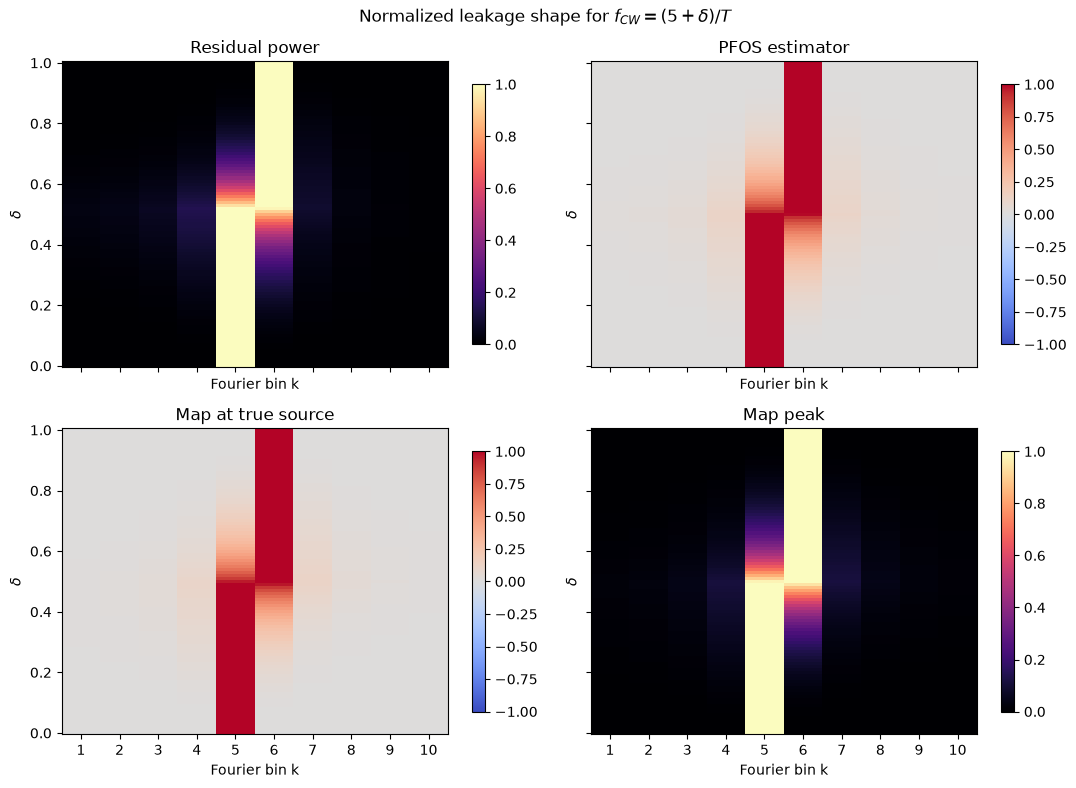

In [35]:
residual_shape_scan = residual_power / np.max(
    np.abs(residual_power), axis=1, keepdims=True
)
pfos_shape_scan = pfos_estimator / np.max(
    np.abs(pfos_estimator), axis=1, keepdims=True
)
source_shape_scan = source_power / np.max(
    np.abs(source_power), axis=1, keepdims=True
)
peak_shape_scan = peak_power / np.max(
    np.abs(peak_power), axis=1, keepdims=True
)

heatmaps = [
    (residual_shape_scan, "Residual power", "magma", 0, 1),
    (pfos_shape_scan, "PFOS estimator", "coolwarm", -1, 1),
    (source_shape_scan, "Map at true source", "coolwarm", -1, 1),
    (peak_shape_scan, "Map peak", "magma", 0, 1),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
extent = [scan_bins[0] - 0.5, scan_bins[-1] + 0.5, -0.005, 1.005]
for ax, (values, title, cmap, vmin, vmax) in zip(axes.flat, heatmaps):
    image = ax.imshow(
        values, origin="lower", aspect="auto", extent=extent,
        cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xticks(scan_bins)
    ax.set_xlabel("Fourier bin k")
    ax.set_ylabel(r"$\delta$")
    fig.colorbar(image, ax=ax, shrink=0.85)
fig.suptitle(r"Normalized leakage shape for $f_{CW}=(5+\delta)/T$")
plt.tight_layout()
plt.show()

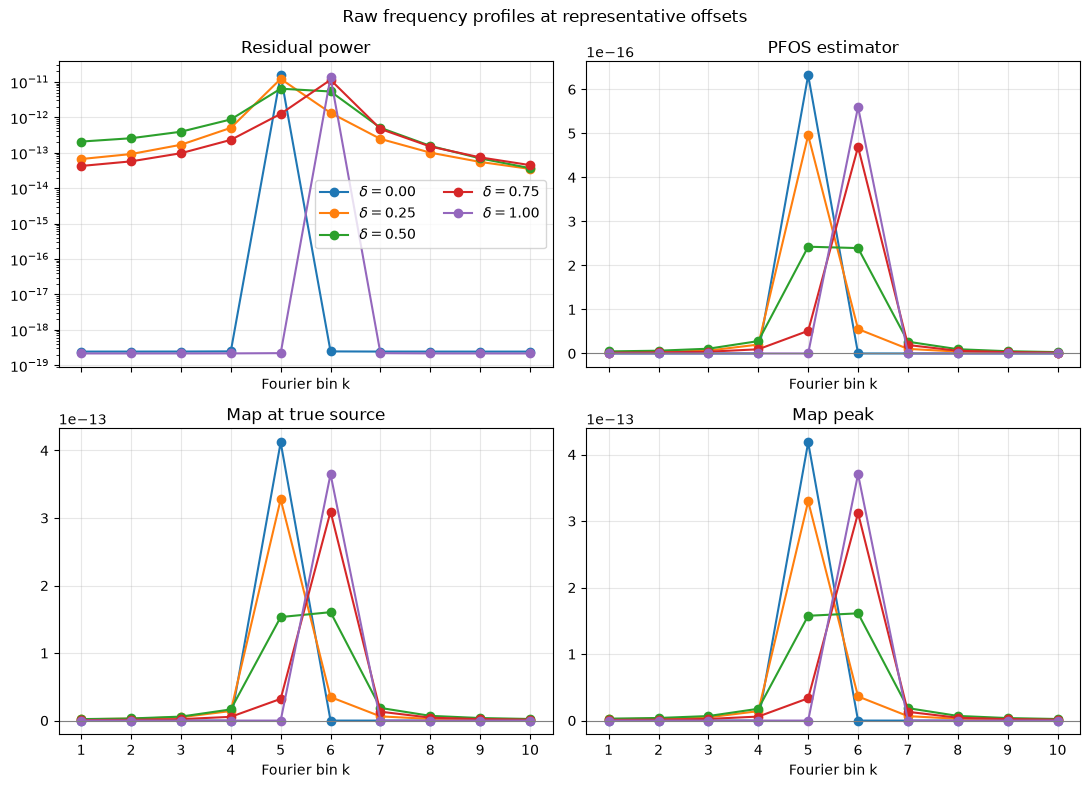

In [36]:
profile_rows = np.array([0, 25, 50, 75, 100])
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for row in profile_rows:
    label = rf"$\delta={delta_values[row]:.2f}$"
    axes[0, 0].semilogy(scan_bins, residual_power[row], "o-", label=label)
    axes[0, 1].plot(scan_bins, pfos_estimator[row], "o-")
    axes[1, 0].plot(scan_bins, source_power[row], "o-")
    axes[1, 1].plot(scan_bins, peak_power[row], "o-")

titles = [
    "Residual power", "PFOS estimator",
    "Map at true source", "Map peak",
]
for ax, title in zip(axes.flat, titles):
    ax.set_title(title)
    ax.set_xticks(scan_bins)
    ax.set_xlabel("Fourier bin k")
    ax.grid(alpha=0.3)
for ax in (axes[0, 1], axes[1, 0], axes[1, 1]):
    ax.axhline(0, color="0.5", linewidth=0.8)
axes[0, 0].legend(ncol=2)
fig.suptitle("Raw frequency profiles at representative offsets")
plt.tight_layout()
plt.show()

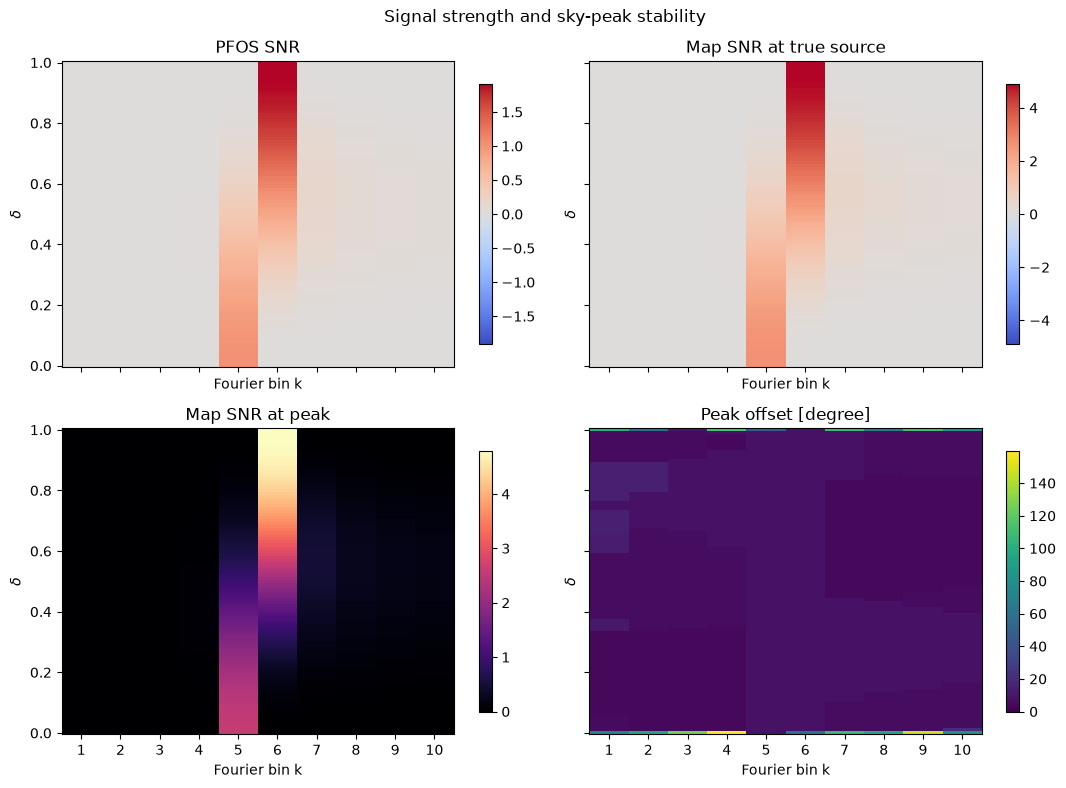

In [37]:
pfos_snr_scan = pfos_estimator / pfos_uncertainty
source_snr_scan = source_power / source_error
peak_snr_scan = peak_power / peak_error
pfos_snr_limit = np.nanmax(np.abs(pfos_snr_scan))
source_snr_limit = np.nanmax(np.abs(source_snr_scan))
peak_snr_limit = np.nanmax(peak_snr_scan)

diagnostics = [
    (pfos_snr_scan, "PFOS SNR", "coolwarm", -pfos_snr_limit, pfos_snr_limit),
    (source_snr_scan, "Map SNR at true source", "coolwarm", -source_snr_limit, source_snr_limit),
    (peak_snr_scan, "Map SNR at peak", "magma", 0, peak_snr_limit),
    (peak_offset_scan, "Peak offset [degree]", "viridis", 0, np.nanmax(peak_offset_scan)),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, (values, title, cmap, vmin, vmax) in zip(axes.flat, diagnostics):
    image = ax.imshow(
        values, origin="lower", aspect="auto", extent=extent,
        cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xticks(scan_bins)
    ax.set_xlabel("Fourier bin k")
    ax.set_ylabel(r"$\delta$")
    fig.colorbar(image, ax=ax, shrink=0.85)
fig.suptitle("Signal strength and sky-peak stability")
plt.tight_layout()
plt.show()

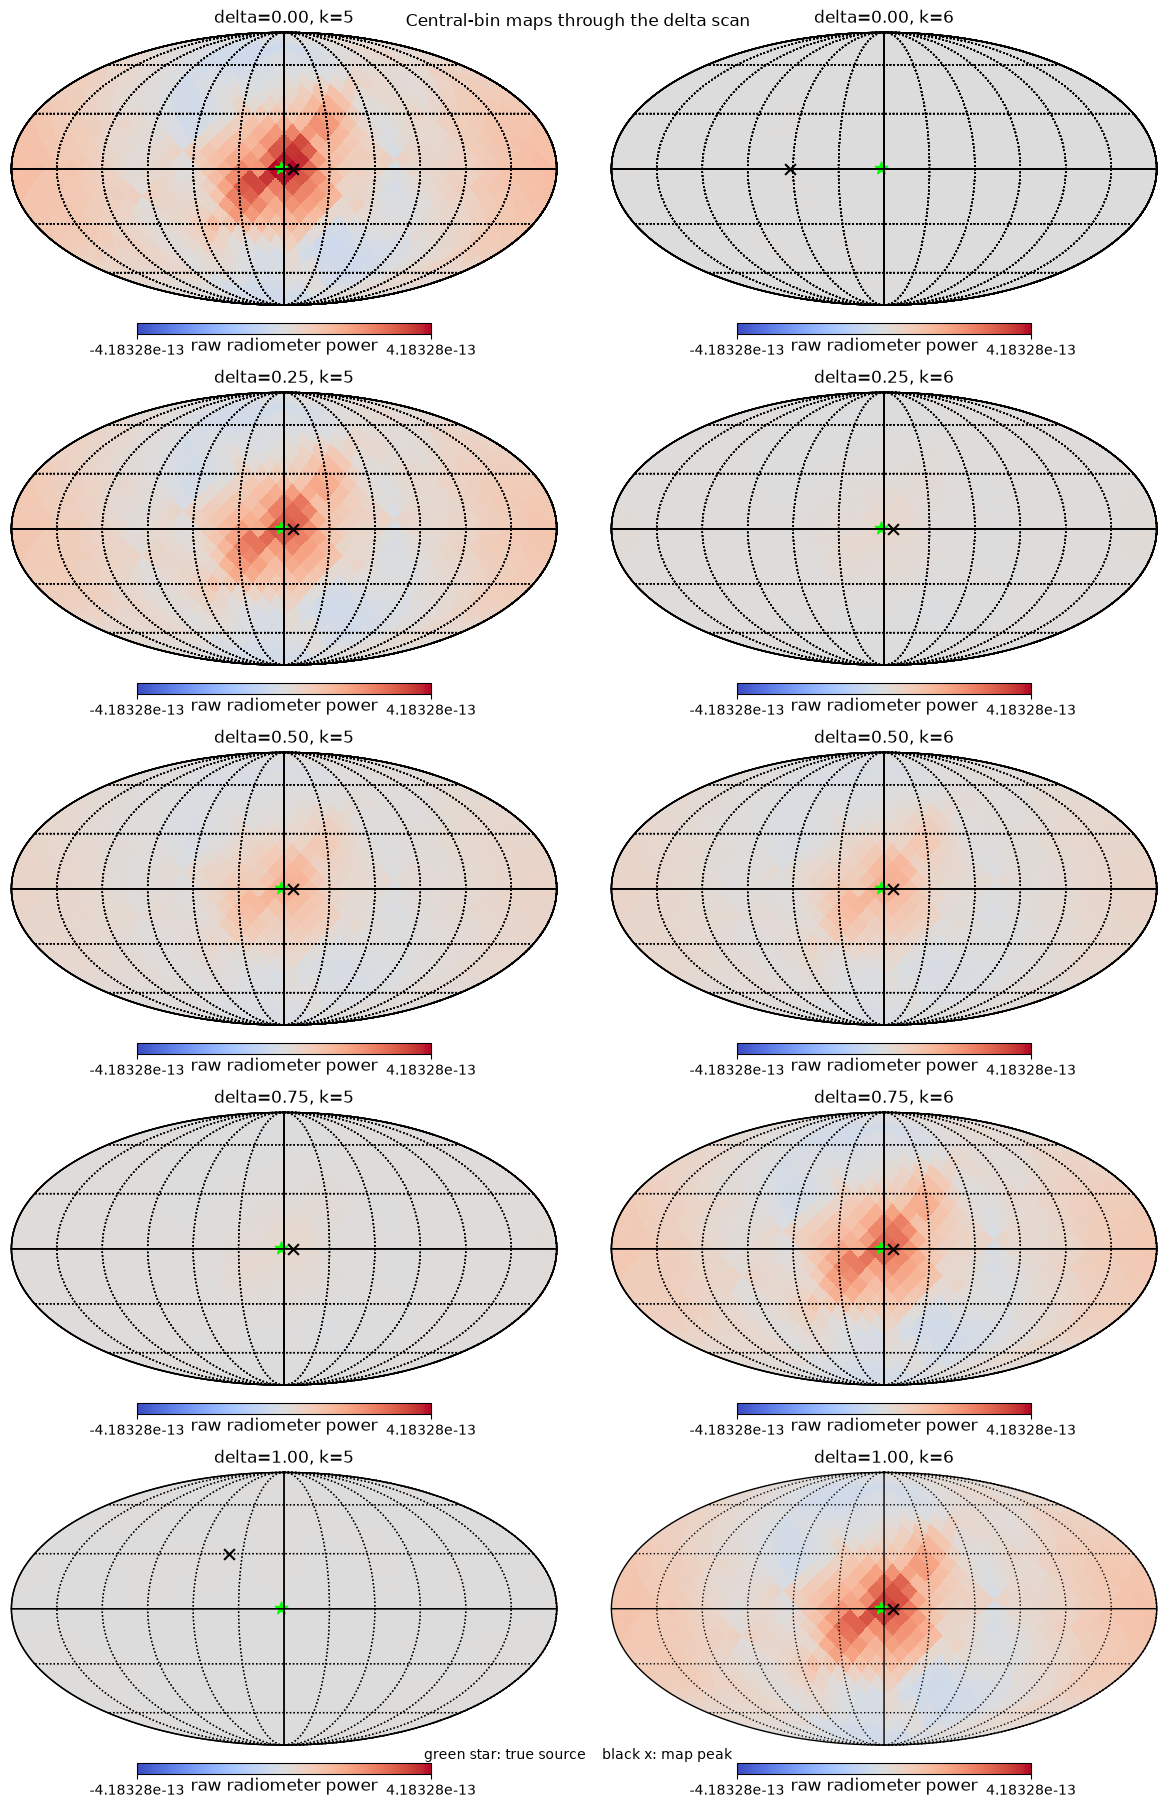

In [38]:
representative_rows = np.array([0, 25, 50, 75, 100])
representative_columns = np.array([
    np.flatnonzero(scan_bins == value)[0] for value in (5, 6)
])
representative_maps = raw_source_maps_scan[
    representative_rows[:, None], representative_columns
]
representative_limit = np.nanmax(np.abs(representative_maps))
fig = plt.figure(figsize=(12, 18))

panel = 1
for row in representative_rows:
    for column in representative_columns:
        hp.mollview(
            raw_source_maps_scan[row, column], fig=fig.number,
            sub=(5, 2, panel), min=-representative_limit,
            max=representative_limit, cmap="coolwarm",
            title=f"delta={delta_values[row]:.2f}, k={scan_bins[column]}",
            unit="raw radiometer power",
        )
        hp.projscatter(gwtheta, gwphi, marker="*", color="lime", s=90)
        peak_theta_one, peak_phi_one = hp.pix2ang(
            NSIDE, peak_pixels_scan[row, column]
        )
        hp.projscatter(
            peak_theta_one, peak_phi_one,
            marker="x", color="black", s=60,
        )
        hp.graticule(verbose=False)
        panel += 1

fig.suptitle("Central-bin maps through the delta scan", y=0.99)
fig.text(0.5, 0.02, "green star: true source    black x: map peak", ha="center")
plt.show()

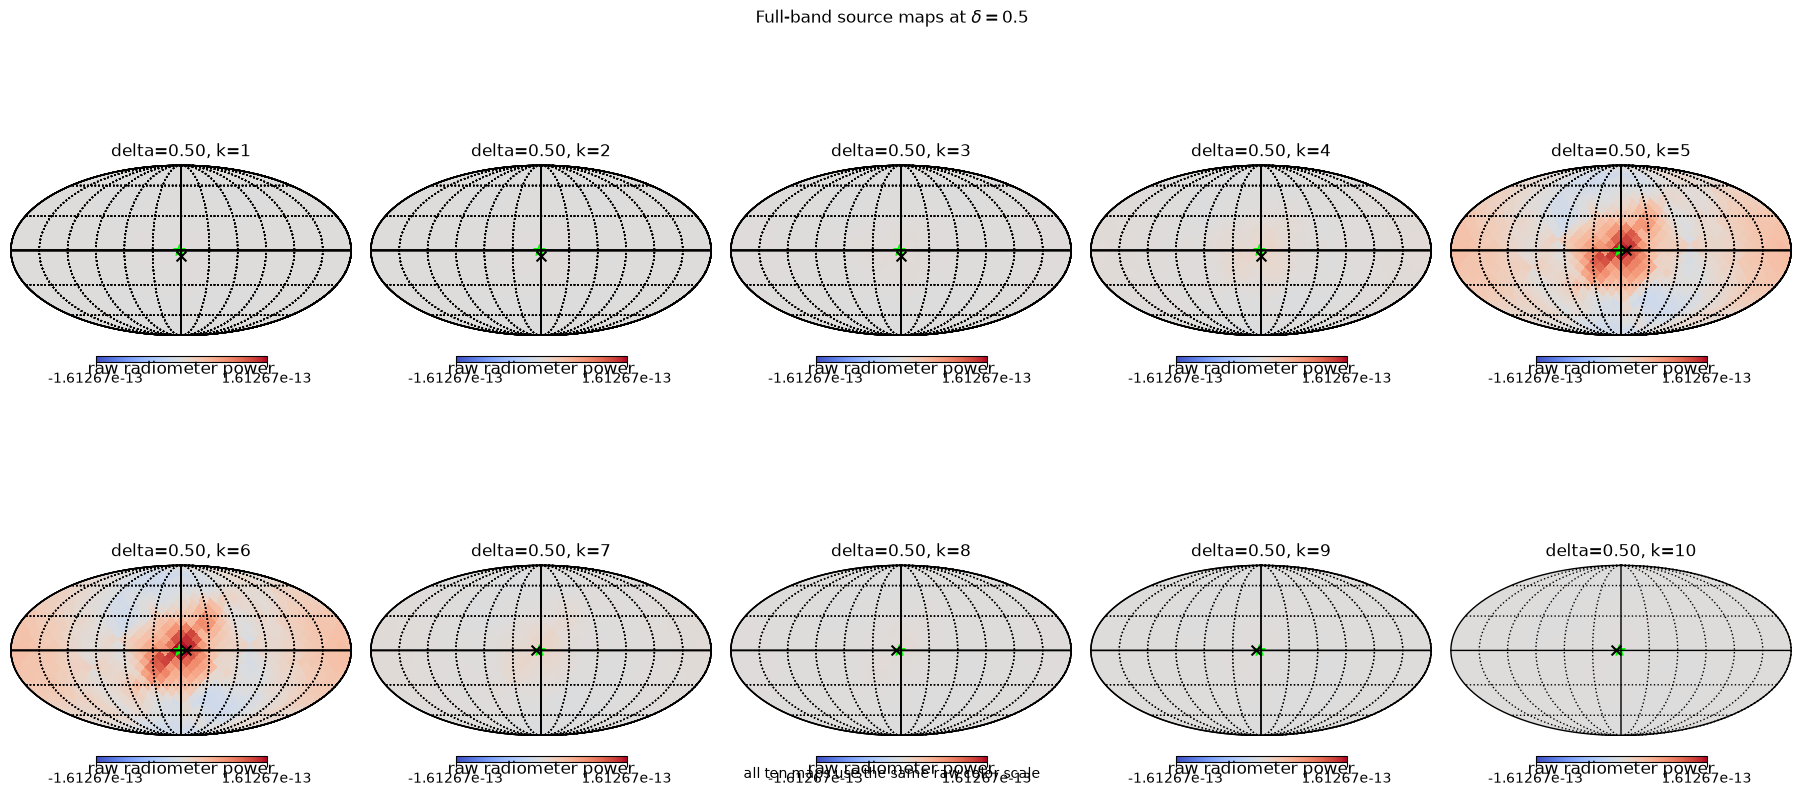

In [39]:
middle_row = np.flatnonzero(delta_values == 0.5)[0]
full_band_maps = raw_source_maps_scan[middle_row]
full_band_limit = np.nanmax(np.abs(full_band_maps))
fig = plt.figure(figsize=(18, 8))

for panel, column in enumerate(range(len(scan_bins)), start=1):
    hp.mollview(
        full_band_maps[column], fig=fig.number,
        sub=(2, 5, panel), min=-full_band_limit,
        max=full_band_limit, cmap="coolwarm",
        title=f"delta=0.50, k={scan_bins[column]}",
        unit="raw radiometer power",
    )
    hp.projscatter(gwtheta, gwphi, marker="*", color="lime", s=70)
    peak_theta_one, peak_phi_one = hp.pix2ang(
        NSIDE, peak_pixels_scan[middle_row, column]
    )
    hp.projscatter(
        peak_theta_one, peak_phi_one,
        marker="x", color="black", s=50,
    )
    hp.graticule(verbose=False)

fig.suptitle(r"Full-band source maps at $\delta=0.5$", y=0.98)
fig.text(0.5, 0.02, "all ten maps use the same raw color scale", ha="center")
plt.show()

In [40]:
summary_rows = np.array([0, 25, 50, 75, 100])
dominant_columns = np.argmax(source_power[summary_rows], axis=1)

scan_summary = pd.DataFrame({
    "delta": delta_values[summary_rows],
    "fgw [nHz]": injection_frequencies[summary_rows] * 1e9,
    "fgw * Tspan": k_cw_values[summary_rows],
    "dominant map bin": scan_bins[dominant_columns],
    "source map power": source_power[
        summary_rows, dominant_columns
    ],
    "source map SNR": source_snr_scan[
        summary_rows, dominant_columns
    ],
    "peak map SNR": peak_snr_scan[
        summary_rows, dominant_columns
    ],
    "peak offset [deg]": peak_offset_scan[
        summary_rows, dominant_columns
    ],
})
scan_summary

,delta,fgw [nHz],fgw * Tspan,dominant map bin,source map power,source map SNR,peak map SNR,peak offset [deg]
0,0.00,15.898453,5.000015,5,4.119842e-13,2.639489,2.577396,7.635423
1,0.25,16.693376,5.250016,5,3.276493e-13,2.099174,2.031253,7.635423
2,0.50,17.488299,5.500016,6,1.605342e-13,2.153016,2.079934,7.635423
3,0.75,18.283221,5.750017,6,3.094861e-13,4.150695,4.022637,7.635423
4,1.00,19.078144,6.000018,6,3.648971e-13,4.893844,4.778643,7.635423


### 扫描结果的边界

热图逐行归一化只用于比较泄漏形状，原始频谱和未归一化数组保存在 NPZ 中。角偏差必须和 map SNR 一起看：信号很弱的 bin 即使出现远处峰值，也不代表可靠的错误定位。这里仍然固定了绝对频段、源方向、偏振、PTA 几何和噪声设置，所以得到的是当前模拟条件下的 $\delta$ 依赖，而不是所有 PTA 的普遍规律。